In [1]:
import pandas as pd 

In [12]:
gen_data = pd.read_csv('/home/s6moakba/InstructABSA/Dataset/AUG/16/Agentic_16_5k.csv')
gen_data = gen_data.sample(n=1800, random_state=41)

In [ ]:
gen_data

In [4]:
with open("/home/s6moakba/InstructABSA/Label_compare/agentic_16_aspe.txt", "r") as file:
    content_agentic = file.read()
    
lines_agent = content_agentic.split('\n')
ag_labels = eval(lines_agent[0].split(': ')[1])
ag_pred = eval(lines_agent[1].split(': ')[1])

ag_df = pd.DataFrame({'aspect': ag_labels, 'pred': ag_pred})
ag_df['aspect'] = ag_df['aspect'].str.replace(", ", ",")
ag_df['pred'] = ag_df['pred'].str.replace(", ", ",")


In [5]:
# Count how many rows have aspect equal to pred
matching_rows = ag_df[ag_df['aspect'] == ag_df['pred']]
matching_count = len(matching_rows)

# Calculate percentage
total_rows = len(ag_df)
matching_percentage = (matching_count / total_rows) * 100

print(f"Number of rows where aspect equals pred: {matching_count} out of {total_rows} ({matching_percentage:.2f}%)")

Number of rows where aspect equals pred: 610 out of 1800 (33.89%)


In [4]:
with open("/home/s6moakba/InstructABSA/Label_compare/prompting_16_aspe.txt", "r") as file:
    content_og = file.read()
    
lines_og = content_og.split('\n')
id_tr_labels = eval(lines_og[0].split(': ')[1])
id_tr_pred_labels = eval(lines_og[1].split(': ')[1])

df = pd.DataFrame({'aspect': id_tr_labels, 'pred': id_tr_pred_labels})
df['aspect'] = df['aspect'].str.replace(", ", ",")
df['pred'] = df['pred'].str.replace(", ", ",")

In [5]:
matching_rows = df[df['aspect'] == df['pred']]
matching_count = len(matching_rows)

# Calculate percentage
total_rows = len(df)
matching_percentage = (matching_count / total_rows) * 100
print(f"Number of rows where aspect equals pred: {matching_count} out of {total_rows} ({matching_percentage:.2f}%)")

Number of rows where aspect equals pred: 330 out of 1800 (18.33%)


In [9]:
gen_data['pred']= ag_df['pred']
# gen_data['pred'] = gen_data['pred'].apply(lambda x: str(x.split(",")))

In [10]:
gen_data.shape

(1800, 7)

In [11]:
gen_data['aspect'] = gen_data['aspect'].str.replace(r"[\'\[\]\"\\]", '', regex=True)
gen_data['aspect'] = gen_data['aspect'].apply(lambda x: x.split(', '))

KeyError: 'aspect'

In [48]:
gen_data['pred'] = gen_data['pred'].str.replace(r"[\'\[\]\"\\]", '', regex=True)
gen_data['pred'] = gen_data['pred'].apply(lambda x: x.split(', '))

In [49]:
gen_data_same = gen_data[gen_data.apply(lambda row: sorted(row['aspect']) == sorted(row['pred']), axis=1)]

In [50]:
gen_data_diff = gen_data[gen_data.apply(lambda row: sorted(row['aspect']) != sorted(row['pred']), axis=1)]

In [53]:
gen_data_diff.shape

(6371, 8)

In [69]:
rowww = gen_data_diff.iloc[3111]
print(rowww['raw_text'])
print(rowww['aspect'])
print(rowww['polarity'])
print(rowww['pred'])

The laptop's 3G network is average, but the sound quality with the headphones is great, unfortunately, the i7 processor is not as powerful as expected.
['3G network', 'headphones', 'i7']
['neutral', 'positive', 'negative']
['3G network', 'sound quality', 'headphones', 'i7 processor']


In [13]:
gen_data_same.shape

(2263, 8)

In [14]:
gen_data_same.to_csv('/home/s6moakba/InstructABSA/Dataset/gen_agent_16_update_ch.csv', index=False)

# /home/s6moakba/InstructABSA/Dataset/gathered_nouns_cap.csv

In [22]:
gen_data_diff = gen_data[gen_data.apply(lambda row: sorted(row['aspect']) != sorted(row['pred']), axis=1)]

In [23]:
gen_data_diff.shape

(1334, 8)

In [28]:
roww = gen_data_diff.iloc[5]
print(roww['raw_text'])
print(roww['aspect'])
print(roww['pred'])

The design of Jekyll and Hyde Pub felt outdated and cluttered, and the arugula and goat cheese dish lacked freshness and flavor
['design', 'Jekyll and Hyde Pub', 'arugula and goat cheese']
['design', 'arugula and goat cheese dish']


/tmp/ipykernel_2387234/1350667901.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gen_data['aspect_length'] = gen_data['aspect'].apply(lambda x: len(x.split(',')))


1590
1290
610
147


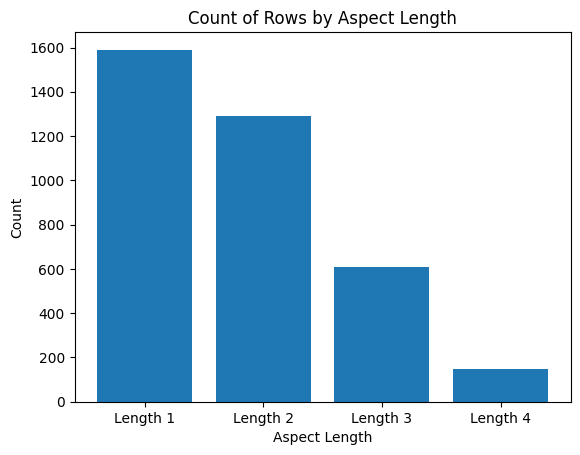

In [ ]:
same_df['aspect_length'] = same_df['aspect'].apply(lambda x: len(x.split(',')))
count_rows_with_length_1 = len(gen_data[gen_data['aspect_length'] == 1])
count_rows_with_length_2 = len(gen_data[gen_data['aspect_length'] == 2])
count_rows_with_length_3 = len(gen_data[gen_data['aspect_length'] == 3])
count_rows_with_length_4 = len(gen_data[gen_data['aspect_length'] == 4])

print(count_rows_with_length_1)
print(count_rows_with_length_2)
print(count_rows_with_length_3)
print(count_rows_with_length_4)
import matplotlib.pyplot as plt

x_labels = ['Length 1', 'Length 2', 'Length 3', 'Length 4']
y_values = [count_rows_with_length_1, count_rows_with_length_2, count_rows_with_length_3,   count_rows_with_length_4]

plt.bar(x_labels, y_values)
plt.xlabel('Aspect Length')
plt.ylabel('Count')
plt.title('Count of Rows by Aspect Length')
plt.show()


In [32]:
len(gen_data)

5918

In [47]:
gen_data.to_csv('/home/s6moakba/InstructABSA/Dataset/gen_train_16_20k_2.csv', index=False)

In [34]:
random_row = gen_data.sample(n=1).iloc[0]
print(random_row['aspectTerms'])
print(random_row['raw_text'])

[{'term': 'sauce', 'polarity': 'Positive'}, {'term': 'pita bread', 'polarity': 'Negative'}, {'term': 'wasabe potatoes', 'polarity': 'Neutral'}]
The sauce was incredibly flavorful but the pita bread was burnt and the wasabe potatoes were just okay.


# check results : 

In [14]:
import pandas as pd 
gen_data = pd.read_csv('/home/s6moakba/Thesis/gen_data_dist_yelp_filtered.csv')

In [20]:
row = gen_data.iloc[12000]
print(row['aspect'])
print(row['raw_text'])

['sammiches', 'carpaccio']
The sammiches were decent, but the carpaccio was a bit of a letdown.


In [23]:
import re
aspect = "['ray\\'s', 'sun']"

safe_aspect = aspect.replace("\\'", "'")

# Step 2: Remove brackets, double quotes, and backslashes
clean_aspect = re.sub(r"[\[\]\"\\]", '', safe_aspect)

# Step 3: Split into list
rough_list = clean_aspect.split(', ')

# Step 4: Strip outer single quotes if they exist
aspect_list = [item.strip("'") for item in rough_list]

print(aspect_list)  # Output: ["ray's", 'sun']


["ray's", 'sun']


In [ ]:
aspect_list[0]

AttributeError: 'str' object has no attribute 'type'